In [1]:
!pip install labelme tensorflow  opencv-python matplotlib albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 68.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 80.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.9/281.9 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 9.5 MB/s eta 0:00:00


In [2]:
import os
import time
import uuid
import cv2

In [3]:
IMAGES_PATH = os.path.join('data','sample')
number_images = 30

In [10]:
import cv2, os, uuid, base64, time
import numpy as np
from google.colab.output import eval_js
from IPython.display import Javascript
from google.colab.patches import cv2_imshow

# Use your existing folder
IMAGES_PATH = "/content/data/images"

# Do NOT create it again
os.makedirs(IMAGES_PATH, exist_ok=True)

# Inject JS once
def js_stream():
  display(Javascript('''
    async function captureMultiple(num_photos, interval, quality) {
      const video = document.createElement('video');
      document.body.appendChild(video);
      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      video.srcObject = stream;
      await video.play();

      const canvas = document.createElement('canvas');
      const context = canvas.getContext('2d');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;

      let photos = [];
      for (let i = 0; i < num_photos; i++) {
        context.drawImage(video, 0, 0);
        photos.push(canvas.toDataURL('image/jpeg', quality));
        await new Promise(resolve => setTimeout(resolve, interval));
      }

      stream.getTracks().forEach(track => track.stop());
      video.remove();
      return photos;
    }
    window.captureMultiple = captureMultiple;
  '''))

# Run JS and collect images
def capture_multiple_photos(num_photos=5, interval=1000, quality=0.8):
  data_list = eval_js(f"captureMultiple({num_photos}, {interval}, {quality})")
  return data_list

# Inject JS first
js_stream()

# Capture photos and save into your existing folder
photos = capture_multiple_photos(num_photos=number_images, interval=1000)

for i, data in enumerate(photos):
    binary = np.frombuffer(base64.b64decode(data.split(',')[1]), dtype=np.uint8)
    img = cv2.imdecode(binary, cv2.IMREAD_COLOR)
    imgname = os.path.join(IMAGES_PATH, f"{str(uuid.uuid1())}.jpg")
    cv2.imwrite(imgname, img)
    print(f"Saved {imgname}")
    cv2_imshow(img)
    time.sleep(0.5)


Output hidden; open in https://colab.research.google.com to view.

In [11]:
from google.colab import files
import shutil

shutil.make_archive("images", 'zip', "/content/data/images")
files.download("images.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
import os, shutil

# Source directory (where JSON files are lying around)
source_dir = "/content"

# Destination directory (must exist already)
dest_dir = "/content/data/images"

# Make sure the destination folder exists
os.makedirs(dest_dir, exist_ok=True)

# Loop through files in source_dir
for file_name in os.listdir(source_dir):
    if file_name.endswith(".jpg"):  # only .json files
        src_path = os.path.join(source_dir, file_name)
        dst_path = os.path.join(dest_dir, file_name)  # destination file path

        # Move the file
        shutil.move(src_path, dst_path)

print("All Jpg files moved into labels folder ✅")


All Jpg files moved into labels folder ✅


In [21]:
import shutil
import os


src = "/content/images"
dst = "/content/data/images"


if os.path.exists(dst):
    shutil.rmtree(dst)


shutil.move(src, dst)

print("'images' folder moved into /content/data/")


✅ 'images' folder moved into /content/data/


In [22]:
import tensorflow as tf
import json
import numpy as np
from matplotlib import pyplot as plt

In [23]:
# Avoid OOM errors by setting GPU Memory Consumption Growth
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [24]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [32]:
images = tf.data.Dataset.list_files('data/images/*.jpg',shuffle=False)


In [33]:
images.as_numpy_iterator().next()

b'data/images/89eae574-8f2d-11f0-8b1b-0242ac1c000c.jpg'

In [34]:
def load_image(x):
    byte_img = tf.io.read_file(x)
    img = tf.io.decode_jpeg(byte_img)
    return img

In [35]:
images = images.map(load_image)

array([[[235, 235, 235],
        [235, 235, 235],
        [235, 235, 235],
        ...,
        [164, 169, 162],
        [163, 170, 162],
        [164, 171, 163]],

       [[235, 235, 235],
        [235, 235, 235],
        [235, 235, 235],
        ...,
        [164, 169, 162],
        [163, 170, 162],
        [164, 171, 163]],

       [[235, 235, 235],
        [235, 235, 235],
        [235, 235, 235],
        ...,
        [164, 169, 162],
        [163, 170, 162],
        [164, 171, 163]],

       ...,

       [[130, 134, 120],
        [129, 133, 119],
        [129, 133, 119],
        ...,
        [111, 103,  84],
        [110, 103,  84],
        [107, 100,  81]],

       [[131, 133, 120],
        [129, 133, 119],
        [128, 132, 118],
        ...,
        [111, 103,  84],
        [110, 103,  84],
        [107, 100,  81]],

       [[130, 132, 119],
        [129, 131, 118],
        [127, 131, 117],
        ...,
        [111, 103,  84],
        [110, 103,  84],
        [107, 100,  81]]], dtype=uint8)
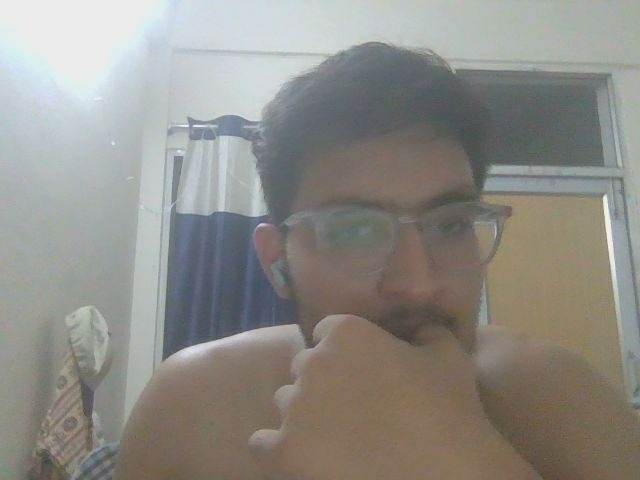

In [36]:
images.as_numpy_iterator().next()

In [37]:
type(images)

tensorflow.python.data.ops.map_op._MapDataset

In [45]:
image_generator = images.batch(5).as_numpy_iterator()

In [46]:
plot_images = image_generator.next()

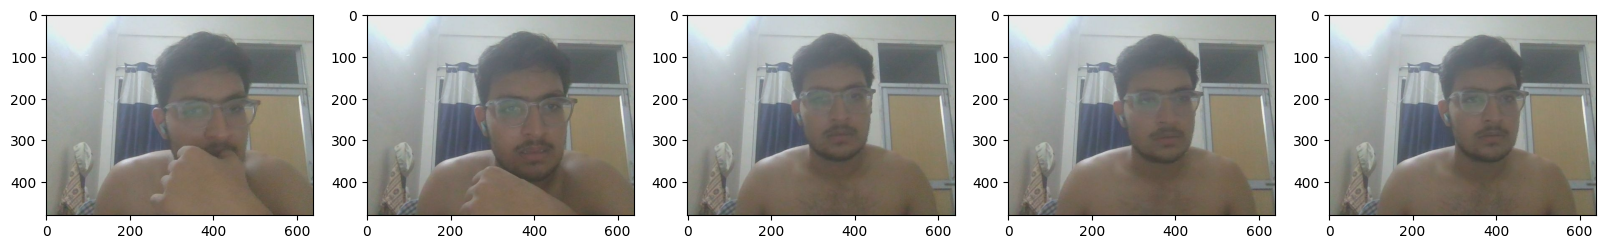

In [48]:
fig, ax = plt.subplots(ncols=5, figsize=(20,20))
for idx, image in enumerate(plot_images):
    ax[idx].imshow(image)
plt.show()

In [50]:
from sklearn.model_selection import train_test_split